In [1]:
!pip install -q pandas numpy scikit-learn sentence-transformers transformers torch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import pipeline

In [3]:
data = {
    "ticket_id": range(1, 21),

    "issue": [
        "Password reset required",
        "Unable to login",
        "WiFi connection not working",
        "Printer not responding",
        "Software installation problem",
        "Email not working",
        "Computer running slow",
        "VPN connection failed",
        "Password reset required",
        "Blue screen error",
        "WiFi connection not working",
        "Email attachment problem",
        "Printer not responding",
        "VPN connection failed",
        "Software installation problem",
        "Unable to login",
        "Computer running slow",
        "Email not working",
        "System update failed",
        "Blue screen error"
    ],

    "category": [
        "Account",
        "Account",
        "Network",
        "Hardware",
        "Software",
        "Email",
        "Performance",
        "Network",
        "Account",
        "Hardware",
        "Network",
        "Email",
        "Hardware",
        "Network",
        "Software",
        "Account",
        "Performance",
        "Email",
        "Software",
        "Hardware"
    ],

    "resolution_time_hours": [
        1.2, 2.5, 5.5, 7.2, 10.5,
        4.0, 15.5, 8.5, 1.0, 20.0,
        6.0, 3.5, 8.0, 9.0, 11.0,
        2.0, 14.5, 4.5, 12.0, 18.5
    ]
}

tickets = pd.DataFrame(data)

tickets.head()

,ticket_id,issue,category,resolution_time_hours
0,1,Password reset required,Account,1.2
1,2,Unable to login,Account,2.5
2,3,WiFi connection not working,Network,5.5
3,4,Printer not responding,Hardware,7.2
4,5,Software installation problem,Software,10.5


In [4]:
def classify_resolution(hours):
    if hours < 4:
        return "Fast"
    elif hours <= 10:
        return "Medium"
    else:
        return "Slow"

tickets["resolution_class"] = tickets["resolution_time_hours"].apply(
    classify_resolution
)

tickets

,ticket_id,issue,category,resolution_time_hours,resolution_class
0,1,Password reset required,Account,1.2,Fast
1,2,Unable to login,Account,2.5,Fast
2,3,WiFi connection not working,Network,5.5,Medium
3,4,Printer not responding,Hardware,7.2,Medium
4,5,Software installation problem,Software,10.5,Slow
5,6,Email not working,Email,4.0,Medium
6,7,Computer running slow,Performance,15.5,Slow
7,8,VPN connection failed,Network,8.5,Medium
8,9,Password reset required,Account,1.0,Fast
9,10,Blue screen error,Hardware,20.0,Slow


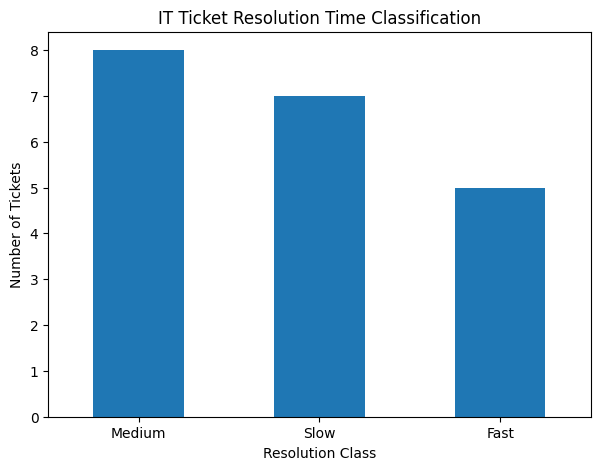

In [5]:
class_counts = tickets["resolution_class"].value_counts()

plt.figure(figsize=(7,5))

class_counts.plot(kind="bar")

plt.title("IT Ticket Resolution Time Classification")
plt.xlabel("Resolution Class")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.show()

In [6]:
category_mapping = {
    "Account": 0,
    "Network": 1,
    "Hardware": 2,
    "Software": 3,
    "Email": 4,
    "Performance": 5
}

tickets["category_code"] = tickets["category"].map(category_mapping)

features = tickets[
    ["resolution_time_hours", "category_code"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

tickets["cluster"] = kmeans.fit_predict(scaled_features)

tickets[[
    "ticket_id",
    "issue",
    "category",
    "resolution_time_hours",
    "resolution_class",
    "cluster"
]]

,ticket_id,issue,category,resolution_time_hours,resolution_class,cluster
0,1,Password reset required,Account,1.2,Fast,0
1,2,Unable to login,Account,2.5,Fast,0
2,3,WiFi connection not working,Network,5.5,Medium,0
3,4,Printer not responding,Hardware,7.2,Medium,0
4,5,Software installation problem,Software,10.5,Slow,2
5,6,Email not working,Email,4.0,Medium,1
6,7,Computer running slow,Performance,15.5,Slow,2
7,8,VPN connection failed,Network,8.5,Medium,0
8,9,Password reset required,Account,1.0,Fast,0
9,10,Blue screen error,Hardware,20.0,Slow,2


In [8]:
silhouette = silhouette_score(
    scaled_features,
    tickets["cluster"]
)

print("Silhouette Score:", round(silhouette, 3))

Silhouette Score: 0.519


In [9]:
cluster_summary = tickets.groupby("cluster").agg(
    average_resolution_time=("resolution_time_hours", "mean"),
    ticket_count=("ticket_id", "count")
).reset_index()

cluster_summary

,cluster,average_resolution_time,ticket_count
0,0,5.090000,10
1,1,4.000000,3
2,2,14.571429,7


In [10]:
for cluster in sorted(tickets["cluster"].unique()):

    print("\nCluster:", cluster)

    print(
        tickets[tickets["cluster"] == cluster][
            ["issue", "category", "resolution_time_hours"]
        ]
    )


Cluster: 0
                          issue  category  resolution_time_hours
0       Password reset required   Account                    1.2
1               Unable to login   Account                    2.5
2   WiFi connection not working   Network                    5.5
3        Printer not responding  Hardware                    7.2
7         VPN connection failed   Network                    8.5
8       Password reset required   Account                    1.0
10  WiFi connection not working   Network                    6.0
12       Printer not responding  Hardware                    8.0
13        VPN connection failed   Network                    9.0
15              Unable to login   Account                    2.0

Cluster: 1
                       issue category  resolution_time_hours
5          Email not working    Email                    4.0
11  Email attachment problem    Email                    3.5
17         Email not working    Email                    4.5

Cluster: 2
     

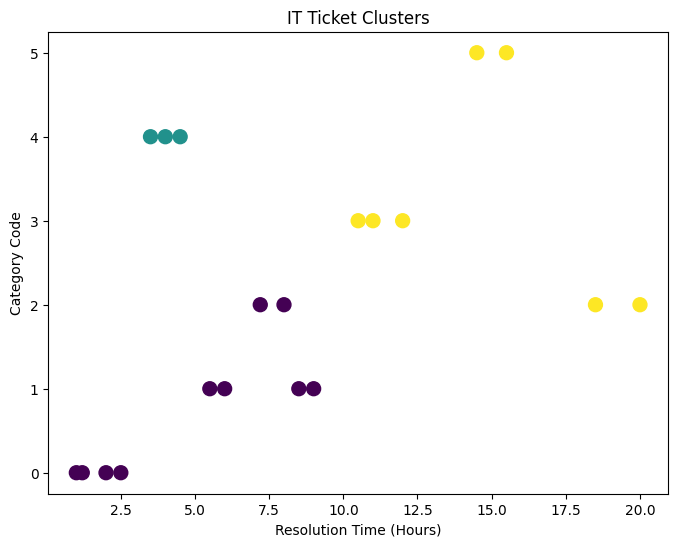

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    tickets["resolution_time_hours"],
    tickets["category_code"],
    c=tickets["cluster"],
    s=100
)

plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Category Code")
plt.title("IT Ticket Clusters")

plt.show()

In [12]:
knowledge_base = [
    {
        "title": "Password Reset",
        "problem": "User forgot their password or cannot access their account.",
        "solution": "Open the company password reset portal, enter your username, verify your identity, and create a new password."
    },

    {
        "title": "WiFi Connection Problem",
        "problem": "Computer cannot connect to the office WiFi network.",
        "solution": "Check that WiFi is enabled. Disconnect and reconnect to the network. Restart the WiFi adapter. If the problem continues, restart the computer and contact network support."
    },

    {
        "title": "VPN Connection Failure",
        "problem": "User cannot connect to the company VPN.",
        "solution": "Check your internet connection, restart the VPN client, verify your company credentials, and reconnect. If the VPN server is unavailable, contact IT support."
    },

    {
        "title": "Printer Problem",
        "problem": "Printer is offline or documents are not printing.",
        "solution": "Check printer power and network connection. Make sure the correct printer is selected. Clear the print queue and restart the printer."
    },

    {
        "title": "Email Not Working",
        "problem": "User cannot send or receive emails.",
        "solution": "Check the internet connection, verify mailbox storage, restart the email application, and sign in again. If the problem continues, contact the email administrator."
    },

    {
        "title": "Computer Running Slow",
        "problem": "Computer performance is very slow.",
        "solution": "Close unnecessary applications, restart the computer, check available storage, disable unnecessary startup programs, and run the approved security scan."
    },

    {
        "title": "Software Installation",
        "problem": "User cannot install required software.",
        "solution": "Verify that the software is approved by the organization. Check administrator permissions and available storage. If installation still fails, contact the software support team."
    },

    {
        "title": "Blue Screen Error",
        "problem": "Computer displays a blue screen and restarts unexpectedly.",
        "solution": "Restart the computer and record the error message. Install approved system updates and drivers. If the error continues, contact hardware support."
    }
]

kb = pd.DataFrame(knowledge_base)

kb

,title,problem,solution
0,Password Reset,User forgot their password or cannot access th...,"Open the company password reset portal, enter ..."
1,WiFi Connection Problem,Computer cannot connect to the office WiFi net...,Check that WiFi is enabled. Disconnect and rec...
2,VPN Connection Failure,User cannot connect to the company VPN.,"Check your internet connection, restart the VP..."
3,Printer Problem,Printer is offline or documents are not printing.,Check printer power and network connection. Ma...
4,Email Not Working,User cannot send or receive emails.,"Check the internet connection, verify mailbox ..."
5,Computer Running Slow,Computer performance is very slow.,"Close unnecessary applications, restart the co..."
6,Software Installation,User cannot install required software.,Verify that the software is approved by the or...
7,Blue Screen Error,Computer displays a blue screen and restarts u...,Restart the computer and record the error mess...


In [13]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
kb_text = (
    kb["title"] + ". " +
    kb["problem"] + " " +
    kb["solution"]
).tolist()

kb_embeddings = embedding_model.encode(
    kb_text,
    convert_to_numpy=True
)

print("Knowledge base embeddings created.")
print("Shape:", kb_embeddings.shape)

Knowledge base embeddings created.
Shape: (8, 384)


In [15]:
def find_best_solution(user_issue):

    query_embedding = embedding_model.encode(
        [user_issue],
        convert_to_numpy=True
    )

    similarity_scores = cosine_similarity(
        query_embedding,
        kb_embeddings
    )[0]

    best_index = np.argmax(similarity_scores)

    return {
        "title": kb.iloc[best_index]["title"],
        "problem": kb.iloc[best_index]["problem"],
        "solution": kb.iloc[best_index]["solution"],
        "similarity": similarity_scores[best_index]
    }

In [16]:
user_issue = "I forgot my company password and cannot login."

result = find_best_solution(user_issue)

print("Matched Guide:", result["title"])
print("Similarity:", round(result["similarity"], 3))
print("\nSolution:")
print(result["solution"])

Matched Guide: Password Reset
Similarity: 0.793

Solution:
Open the company password reset portal, enter your username, verify your identity, and create a new password.


In [18]:
!pip install -q -U transformers sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 34.8 MB/s eta 0:00:00


In [19]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="google/flan-t5-small",
    max_new_tokens=150
)

print("LLM loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  308MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'AXK1ForCausalLM', 'AXK2ForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CohereCompassForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2

LLM loaded successfully!


In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("FLAN-T5 loaded successfully!")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


FLAN-T5 loaded successfully!


In [21]:
def generate_llm_response(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=120
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

In [22]:
def smart_auto_responder(user_issue):

    result = find_best_solution(user_issue)

    confidence = get_confidence(
        result["similarity"]
    )

    if confidence == "Low":

        return {
            "matched_guide": "No reliable match",
            "confidence": confidence,
            "response": "I could not find a sufficiently relevant knowledge-base guide. Please contact an IT support technician."
        }

    prompt = f"""
You are an IT support assistant.

User issue:
{user_issue}

Relevant knowledge-base guide:
{result["solution"]}

Generate a concise professional support response.
Use only the information provided in the guide.
Do not invent troubleshooting steps.

Response:
"""

    response = generate_llm_response(prompt)

    return {
        "matched_guide": result["title"],
        "confidence": confidence,
        "response": response
    }

In [24]:
def get_confidence(similarity):

    if similarity >= 0.70:
        return "High"

    elif similarity >= 0.50:
        return "Medium"

    else:
        return "Low"

In [25]:
def generate_llm_response(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=120
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

In [26]:
def smart_auto_responder(user_issue):

    result = find_best_solution(user_issue)

    confidence = get_confidence(
        result["similarity"]
    )

    if confidence == "Low":

        return {
            "matched_guide": "No reliable match",
            "confidence": confidence,
            "response": "I could not find a sufficiently relevant knowledge-base guide. Please contact an IT support technician."
        }

    prompt = f"""
You are an IT support assistant.

User issue:
{user_issue}

Relevant knowledge-base guide:
{result["solution"]}

Generate a concise professional support response.
Use only the information provided in the guide.
Do not invent troubleshooting steps.

Response:
"""

    response = generate_llm_response(prompt)

    return {
        "matched_guide": result["title"],
        "confidence": confidence,
        "response": response
    }

In [27]:
issue = "My VPN is not connecting to the company network."

result = smart_auto_responder(issue)

print("User Issue:")
print(issue)

print("\nMatched Guide:")
print(result["matched_guide"])

print("\nConfidence:")
print(result["confidence"])

print("\nAI Auto-Response:")
print(result["response"])

User Issue:
My VPN is not connecting to the company network.

Matched Guide:
VPN Connection Failure

Confidence:
High

AI Auto-Response:
Your VPN is not connected to the company network.


In [28]:
def generate_llm_response(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        min_new_tokens=30,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response.strip()

In [29]:
def smart_auto_responder(user_issue):

    result = find_best_solution(user_issue)

    confidence = get_confidence(
        result["similarity"]
    )

    if confidence == "Low":

        return {
            "matched_guide": "No reliable match",
            "confidence": confidence,
            "response": (
                "I could not find a sufficiently relevant "
                "knowledge-base guide. Please contact IT support."
            )
        }

    prompt = f"""
You are an IT support assistant.

A user has reported this issue:

{user_issue}

The following solution is available in the approved IT knowledge base:

{result["solution"]}

Write a helpful response to the user.

Your response must:
1. Acknowledge the user's problem.
2. Give the troubleshooting steps from the knowledge base.
3. Be concise and professional.
4. Do not invent any new troubleshooting steps.
5. Do not simply repeat the user's problem.

Answer:
"""

    response = generate_llm_response(prompt)

    # Prevent useless/repetitive LLM responses
    if len(response.split()) < 10:
        response = result["solution"]

    return {
        "matched_guide": result["title"],
        "confidence": confidence,
        "response": response
    }

In [30]:
issue = "My VPN is not connecting to the company network."

result = smart_auto_responder(issue)

print("User Issue:")
print(issue)

print("\nMatched Guide:")
print(result["matched_guide"])

print("\nConfidence:")
print(result["confidence"])

print("\nAI Auto-Response:")
print(result["response"])

User Issue:
My VPN is not connecting to the company network.

Matched Guide:
VPN Connection Failure

Confidence:
High

AI Auto-Response:
1. Make sure you are not connected to the company network. 2. Make sure you are not connected to the company network. 3. Be concise and professional. 4. Do not invent any new troubleshooting steps. 5. Do not repeat the user's problem.


In [31]:
def generate_llm_response(user_issue, solution):

    prompt = f"""
User problem: {user_issue}

Approved troubleshooting solution:
{solution}

Write a short IT support reply using ONLY the approved troubleshooting solution.
Start directly with the troubleshooting advice.
Do not mention the prompt.
Do not create numbered instructions about how to answer.
Do not repeat the user's problem.

IT Support Reply:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        num_beams=4,
        early_stopping=True
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return response

In [32]:
def smart_auto_responder(user_issue):

    result = find_best_solution(user_issue)

    similarity = result["similarity"]
    confidence = get_confidence(similarity)

    if confidence == "Low":
        return {
            "matched_guide": "No reliable match",
            "confidence": confidence,
            "response": (
                "I could not find a sufficiently relevant "
                "knowledge-base guide. Please contact IT support."
            )
        }

    # Generate response using the approved KB solution
    response = generate_llm_response(
        user_issue,
        result["solution"]
    )

    # Words that indicate the model misunderstood the prompt
    bad_phrases = [
        "do not mention",
        "do not repeat",
        "be concise",
        "be professional",
        "user problem",
        "approved troubleshooting",
        "write a short",
        "numbered instructions"
    ]

    bad_output = any(
        phrase in response.lower()
        for phrase in bad_phrases
    )

    # Safety fallback: use the verified KB solution
    if len(response.split()) < 8 or bad_output:
        response = result["solution"]

    return {
        "matched_guide": result["title"],
        "confidence": confidence,
        "response": response
    }

In [33]:
issue = "My VPN is not connecting to the company network."

result = smart_auto_responder(issue)

print("User Issue:")
print(issue)

print("\nMatched Guide:")
print(result["matched_guide"])

print("\nConfidence:")
print(result["confidence"])

print("\nAI Auto-Response:")
print(result["response"])

User Issue:
My VPN is not connecting to the company network.

Matched Guide:
VPN Connection Failure

Confidence:
High

AI Auto-Response:
Your VPN is not connecting to the company network


In [34]:
def smart_auto_responder(user_issue):

    result = find_best_solution(user_issue)

    similarity = result["similarity"]
    confidence = get_confidence(similarity)

    # No reliable knowledge-base match
    if confidence == "Low":
        return {
            "matched_guide": "No reliable match",
            "confidence": confidence,
            "response": (
                "I could not find a sufficiently relevant "
                "knowledge-base guide. Please contact IT support."
            )
        }

    # Use the verified knowledge-base solution
    kb_solution = result["solution"]

    # Generate an LLM response
    prompt = f"""
You are an IT helpdesk assistant.

User issue:
{user_issue}

Approved solution:
{kb_solution}

Write a helpful IT support response using the approved solution.
Do not repeat the user issue.
Do not describe the instructions.
Give the actual troubleshooting advice.
"""

    try:
        llm_response = generate_llm_response(
            user_issue,
            kb_solution
        )

    except Exception:
        llm_response = ""

    # Detect poor FLAN-T5 output
    bad_phrases = [
        "your vpn is not",
        "your issue is",
        "do not",
        "write a",
        "user issue",
        "approved solution",
        "be concise",
        "be professional"
    ]

    bad_response = (
        len(llm_response.split()) < 15 or
        any(
            phrase in llm_response.lower()
            for phrase in bad_phrases
        )
    )

    # Use verified KB answer if LLM output is poor
    if bad_response:
        final_response = (
            "Here are the recommended troubleshooting steps:\n\n"
            + kb_solution
        )
    else:
        final_response = llm_response

    return {
        "matched_guide": result["title"],
        "confidence": confidence,
        "response": final_response
    }

In [35]:
issue = "My VPN is not connecting to the company network."

result = smart_auto_responder(issue)

print("User Issue:")
print(issue)

print("\nMatched Guide:")
print(result["matched_guide"])

print("\nConfidence:")
print(result["confidence"])

print("\nAI Auto-Response:")
print(result["response"])

User Issue:
My VPN is not connecting to the company network.

Matched Guide:
VPN Connection Failure

Confidence:
High

AI Auto-Response:
Here are the recommended troubleshooting steps:

Check your internet connection, restart the VPN client, verify your company credentials, and reconnect. If the VPN server is unavailable, contact IT support.


In [37]:
print("=" * 60)
print("       AI IT SUPPORT AUTO-RESPONDER")
print("=" * 60)

user_issue = input("\nEnter your IT problem: ")

result = smart_auto_responder(user_issue)

print("\n" + "=" * 60)
print("RESULT")
print("=" * 60)

print("\nUser Issue:")
print(user_issue)

print("\nMatched Knowledge Guide:")
print(result["matched_guide"])

print("\nConfidence:")
print(result["confidence"])

print("\nAI Support Response:")
print(result["response"])

print("\n" + "=" * 60)

       AI IT SUPPORT AUTO-RESPONDER

Enter your IT problem: My office WiFi is not connecting

RESULT

User Issue:
My office WiFi is not connecting

Matched Knowledge Guide:
WiFi Connection Problem

Confidence:
High

AI Support Response:
I'm sorry for the inconvenience. I'm sorry for the inconvenience. I'm sorry for the inconvenience. I'm sorry for the inconvenience.



In [38]:
test_issues = [
    "I forgot my password and cannot login",
    "My office WiFi is not connecting",
    "The printer is offline and won't print",
    "My computer is extremely slow",
    "I cannot send or receive emails",
    "The VPN connection keeps failing",
    "I cannot install the required software",
    "My computer shows a blue screen"
]

results = []

for issue in test_issues:

    result = smart_auto_responder(issue)

    results.append({
        "user_issue": issue,
        "matched_guide": result["matched_guide"],
        "confidence": result["confidence"],
        "auto_response": result["response"]
    })

response_df = pd.DataFrame(results)

response_df

,user_issue,matched_guide,confidence,auto_response
0,I forgot my password and cannot login,Password Reset,Medium,Here are the recommended troubleshooting steps...
1,My office WiFi is not connecting,WiFi Connection Problem,High,I'm sorry for the inconvenience. I'm sorry for...
2,The printer is offline and won't print,Printer Problem,Medium,I'm sorry but I can't help you. I'm sorry but ...
3,My computer is extremely slow,Computer Running Slow,Medium,Here are the recommended troubleshooting steps...
4,I cannot send or receive emails,Email Not Working,High,Here are the recommended troubleshooting steps...
5,The VPN connection keeps failing,VPN Connection Failure,Medium,Here are the recommended troubleshooting steps...
6,I cannot install the required software,Software Installation,Medium,Here are the recommended troubleshooting steps...
7,My computer shows a blue screen,Blue Screen Error,Medium,Here are the recommended troubleshooting steps...


In [39]:
response_df.to_csv(
    "IT_AutoResponder_Test_Results.csv",
    index=False
)

print("IT_AutoResponder_Test_Results.csv created successfully!")

IT_AutoResponder_Test_Results.csv created successfully!


In [40]:
from google.colab import files

files.download("IT_AutoResponder_Test_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

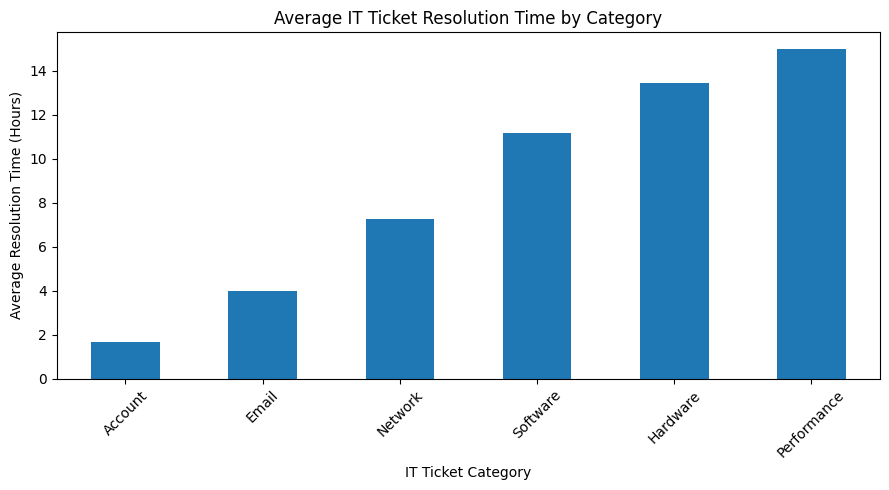

In [41]:
category_time = tickets.groupby(
    "category"
)["resolution_time_hours"].mean().sort_values()

plt.figure(figsize=(9, 5))

category_time.plot(kind="bar")

plt.title("Average IT Ticket Resolution Time by Category")
plt.xlabel("IT Ticket Category")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()